# Investigation Into Modeling of `RBP PPI` Events

## Purpose: 

{TODO}

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

import polars as pl 
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(100000)
_=pl.Config.set_tbl_width_chars(10000)

%load_ext autoreload 
%autoreload 2
    
import importlib

RbpPpiAnalyzer = getattr(
    importlib.import_module("rbp_ppi_analyzer"), 
    "RbpPpiAnalyzer"
)


## Initialize Class

In [2]:
cell_lines = ["K562", "HepG2"]
best_performing_distance_threshold = 100

analyzers = {}

In [3]:
for cell_line in cell_lines: 
    
    analyzers[cell_line] = RbpPpiAnalyzer(
        cell_line = cell_line, 
        distance_threshold = best_performing_distance_threshold
    )

2024-11-06 18:57:48.464 | SUCCESS  | rbp_ppi_analyzer:load_RBP_PPI_pairs:50 - FROM CACHE: RBP PPI info for K562 loaded
2024-11-06 18:57:48.464 | INFO     | rbp_ppi_analyzer:load_linear_model_results:63 - FROM CACHE: Loading linear model predictions for K562 100.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
2024-11-06 18:58:03.467 | SUCCESS  | rbp_ppi_analyzer:load_linear_model_results:74 - Retrieved linear model predictions for K562 100.
2024-11-06 18:58:03.468 | INFO     | rbp_ppi_analyzer:load_SHAP_data:54 - FROM CACHE: Loading SHAP data for K562 100
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
2024-11-06 18:58:22.617 | SUCCESS  | rbp_ppi_analyzer:load_SHAP_data:59 - Loaded SHAP data for K562 100
2024-11-06 18:58:22.618 | INFO     | rbp_ppi_analyzer:retrieve_rbp_ppi_events_and_controls:135 - Retrieving RBP PPI events and controls.
Mismatche

<h1 style="color: #39FF14; font-weight: bold; font-size: 48px;">XGBoost vs Linear Regression Model Comparison</h1>

## How does performance compare between the 2 models?

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].compare_xgboost_and_linear_model_predictions()

## How do `XGBoost` and `Linear Regression` compare to each other (performance-wise) when only looking at events where there are RBP PPIs?


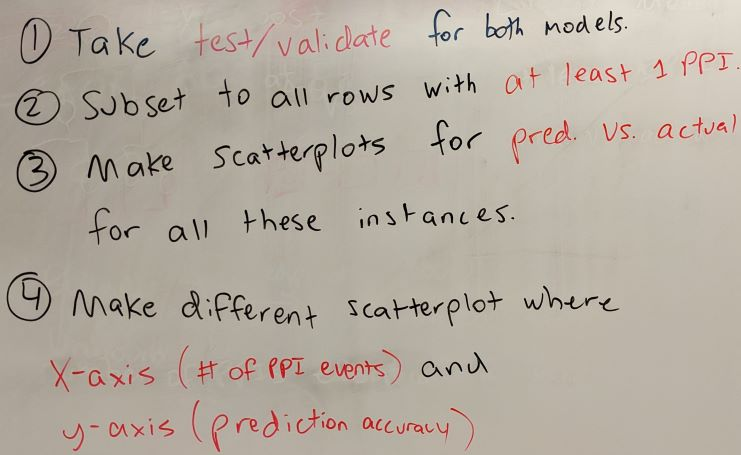

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].compare_rbp_ppi_performance_xgboost_vs_linear_model()

In [ ]:
for cell_line in analyzers: 
    analyzers[cell_line].plot_beta_coefficients_vs_global_SHAP()
    